# Spin-basis 2D — ansatz comparison

Every sweep under `spinbasis_data_2d/`, merged. Two rounds so far on the same
6x6 $J_1$ model ($J_2 = 0$):

**2026-09-28** — four ansätze at `sign_rule = "FF"`, complex parameters:
Jastrow (630p), RBM $\alpha$=1 (1 368p), RBM $\alpha$=2 (2 700p), ViT d=72 patch 2
(116 784p).

**2026-09-30** — follow-up: two *symmetric* RBMs (`RBMSymm`, 296p each — 8 feature
maps either way, since parameters depend only on the feature count and not on
$|G|$) at `sign_rule = "TF"` with real parameters, plus two reshaped ViTs
(d=36 patch 2, 29 880p; d=72 patch 3, 117 024p).

Both symmetric RBMs **collapsed to the Néel state** and were stopped at step 60
by the freeze guard — see the collapse section. They are kept in the tables and
plots as failures rather than dropped.

Data layout: one `run_000X/` per column. Logs are NetKet `JsonLog` files named
`run step NNNNNN.log`, one per resubmission window, with *global* iteration
numbers, so every `*.log` in a run dir is merged and sorted. Sampling health is
appended to a single `run.diag.jsonl`.

In [1]:
from pathlib import Path
import json, re
import numpy as np
import matplotlib.pyplot as plt

def _data_root(name="spinbasis_data_2d"):
    here = Path.cwd().resolve()
    for base in (here, *here.parents):
        if (base / name).is_dir():
            return base / name
    raise FileNotFoundError(f"no {name!r} directory at or above {here}")

DATA_ROOT = _data_root()

# Every sweep folder, oldest first. Trim this list to focus on one round.
SWEEP_DIRS = sorted((p for p in DATA_ROOT.iterdir()
                     if p.is_dir() and (p / "matrix.json").exists()),
                    key=lambda p: p.name)

# 6x6, J2 = 0 reference (per site). ED is skipped at this size, so E0 is null in
# run.summary.json and this literal is the only reference available.
E0_PER_SITE = -0.678872

SMOOTH = 101        # rolling-mean window, in steps, for the trend lines

for p in SWEEP_DIRS:
    print("sweep:", p.name)

sweep: 2026-09-28_15-04-11G50d5e6fP3681539 2
sweep: 2026-09-30_15-42-22G9ceefb5P1029691


## Load

In [2]:
def _column(block, name):
    """NetKet writes a complex series as {"real": [...], "imag": [...]} and a
    real one as a plain list -- the float64 RBMSymm runs hit the second form."""
    col = block[name]
    if isinstance(col, dict):
        col = col["real"]
    return np.asarray(col, dtype=float)


def _merge_logs(run_dir):
    """Every *.log in a run dir -> one curve sorted by global iteration."""
    series = {}
    for lp in sorted(run_dir.glob("*.log")):
        E = json.load(open(lp))["Energy"]
        for i, m, s, v, rh in zip(E["iters"], _column(E, "Mean"),
                                  _column(E, "Sigma"), _column(E, "Variance"),
                                  _column(E, "R_hat")):
            series[int(i)] = (m, s, v, rh)
    it = np.array(sorted(series))
    cols = np.array([series[i] for i in it], dtype=float)
    return it, cols[:, 0], cols[:, 1], cols[:, 2], cols[:, 3]


def _diag(run_dir):
    """run.diag.jsonl -> dict of arrays (append-only, global step)."""
    p = run_dir / "run.diag.jsonl"
    if not p.exists():
        return {}
    rows = [json.loads(l) for l in p.open() if l.strip()]
    keys = ("step", "var_eloc_per_site", "ess_w_frac", "rhat_logpsi", "acceptance")
    return {k: np.array([r.get(k, np.nan) for r in rows], dtype=float) for k in keys}


def _from_stdout(run_dir):
    """The driver prints the ansatz and its parameter count; summary.json is
    missing for runs killed before they could write it, so prefer stdout."""
    txt = (run_dir / "stdout.txt").read_text(errors="replace")
    wf = re.search(r"^wavefunction:\s*(.+)$", txt, re.M)
    npar = re.search(r"n_params=(\d+)", txt)
    return (wf.group(1).strip() if wf else "?",
            int(npar.group(1)) if npar else None)


def _status(run_dir):
    for flag, name in (("run.done", "completed"),
                       ("run.timeout", "timeout"),
                       ("run.frozen", "frozen")):     # freeze guard stopped it
        if (run_dir / flag).exists():
            return name
    return "no sentinel"       # still running, or killed before it could write


def _identify(cfg):
    """(family, panel, short name) from the resolved config -- not from
    sweep_values, which only lists the keys that round happened to sweep."""
    m = cfg["model"]
    t = m["type"]
    if t == "jastrow":
        return "jastrow", "RBM-like", "Jastrow"
    if t == "rbm":
        a = m["rbm"]["alpha"]
        symm = m["rbm"].get("symmetries", "none")
        if symm == "none":
            return "rbm", "RBM-like", rf"RBM $\alpha$={a:g}"
        short = {"translation": "transl", "space_group": "space grp"}.get(symm, symm)
        return "rbmsymm", "RBM-like", f"RBMSymm {short}"
    v = m["vit"]
    return "vit", "ViT", f"ViT d={v['d_model']} p={v['patch_size']}"


runs = []
for sweep_dir in SWEEP_DIRS:
    matrix = json.load(open(sweep_dir / "matrix.json"))
    tag = sweep_dir.name[5:10]              # MM-DD, enough to tell rounds apart
    for spec in matrix["runs"]:
        run_dir = sweep_dir / f"run_{spec['run_id']:04d}"
        it, E, sigma, var, rhat = _merge_logs(run_dir)
        cfg = spec["config"]
        wf, n_params = _from_stdout(run_dir)
        family, panel, name = _identify(cfg)
        runs.append({
            "sweep": sweep_dir.name, "tag": tag, "id": spec["run_id"],
            "dir": run_dir, "family": family, "panel": panel, "name": name,
            "wf": wf, "n_params": n_params, "sign_rule": cfg["system"]["sign_rule"],
            "n_sites": cfg["system"]["L"] ** 2, "status": _status(run_dir),
            "target": cfg["model"]["iter"],
            "iters": it, "E": E, "sigma": sigma, "var": var, "rhat": rhat,
            "diag": _diag(run_dir),
        })

# Categorical slots 1-8 of the reference palette, in its canonical order. Colour
# is assigned WITHIN a panel, so no panel ever shows more than five of them and
# each panel's set stays in canonical order; every curve is also direct-labelled,
# so identity is never carried by colour alone.
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
           "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
PANELS = ["RBM-like", "ViT"]
for panel in PANELS:
    for slot, r in enumerate(x for x in runs if x["panel"] == panel):
        r["color"] = PALETTE[slot % len(PALETTE)]

def label(r):
    return f"{r['name']}  [{r['tag']}, {r['n_params']:,}p]"

TAIL = 200

def _tail(arr, cap=TAIL):
    """The last `cap` entries, but never more than a quarter of the series.

    One VMC step is a noisy estimator, so a run's energy is a tail mean rather
    than its last point. The quarter-cap matters for the runs that were stopped
    after 60 steps: a flat 200-step window is the whole run there, so it would
    average the pre-collapse descent into the collapsed value and report
    -0.502 for a wavefunction that has been at exactly -0.5 since step 20."""
    n = max(1, min(cap, len(arr) // 4))
    return arr[-n:]

for r in runs:
    tail = _tail(r["E"]) / r["n_sites"]
    r["e_final"], r["e_std"] = tail.mean(), tail.std()
    r["rel_err"] = abs(r["e_final"] - E0_PER_SITE) / abs(E0_PER_SITE)
    r["var_final"] = _tail(r["var"]).mean() / r["n_sites"]
    r["n_tail"] = len(tail)
    d = r["diag"]
    r["acc_final"] = (float(np.nanmean(_tail(d["acceptance"], 10)))
                      if d else np.nan)

for r in runs:
    print(f"{r['tag']}/run_{r['id']:04d}  {r['wf'][:58]:58s}  "
          f"{len(r['iters']):5d}/{r['target']}  {r['status']}")

09-28/run_0000  Jastrow(param_dtype=complex128, init_std=default)            2948/10000  no sentinel
09-28/run_0001  RBM(alpha=1.0, param_dtype=complex128, use_visible_bias=Tr   2978/10000  no sentinel
09-28/run_0002  RBM(alpha=2.0, param_dtype=complex128, use_visible_bias=Tr  10000/10000  completed
09-28/run_0003  ViT(num_layers=2, d_model=72, n_heads=12, patch_size=2 ->   10000/10000  completed
09-30/run_0000  RBMSymm(alpha=8.0 -> 8 feature maps, symmetries=translatio     60/10000  frozen
09-30/run_0001  RBMSymm(alpha=64.0 -> 8 feature maps, symmetries=space_gro     60/10000  frozen
09-30/run_0002  ViT(num_layers=2, d_model=36, n_heads=6, patch_size=2 -> 9  10000/10000  completed
09-30/run_0003  ViT(num_layers=2, d_model=72, n_heads=12, patch_size=3 ->   10000/10000  completed


## All runs

In [3]:
hdr = (f"{'sweep':>6} {'run':>4} {'ansatz':>16} {'sign':>5} {'n_params':>9} "
       f"{'steps':>6} {'status':>11} {'E/site':>11} {'rel.err':>9} "
       f"{'Var/site':>10} {'acc':>6}")
print(hdr)
print("-" * len(hdr))
for r in sorted(runs, key=lambda r: r["rel_err"]):
    plain = re.sub(r"[$\\]|alpha", lambda m: "a" if m.group() == "alpha" else "",
                   r["name"])
    print(f"{r['tag']:>6} {r['id']:>4} {plain:>16} {r['sign_rule']:>5} "
          f"{r['n_params']:>9,} {len(r['iters']):>6} {r['status']:>11} "
          f"{r['e_final']:>11.6f} {r['rel_err']:>9.2e} "
          f"{r['var_final']:>10.2e} {r['acc_final']:>6.2f}")
print(f"\nreference E0/site = {E0_PER_SITE:.6f}  (6x6, J2 = 0), best first")
print("E/site, Var/site and acc are means over the final min(200, 25% of run) "
      "steps:\n  " + ", ".join(f"{r['tag']}/{r['id']}={r['n_tail']}" for r in runs))

 sweep  run           ansatz  sign  n_params  steps      status      E/site   rel.err   Var/site    acc
-------------------------------------------------------------------------------------------------------
 09-28    3     ViT d=72 p=2    FF   116,784  10000   completed   -0.678868  6.21e-06   2.85e-05   0.28
 09-30    2     ViT d=36 p=2    FF    29,880  10000   completed   -0.678863  1.34e-05   6.74e-05   0.27
 09-30    3     ViT d=72 p=3    FF   117,024  10000   completed   -0.678850  3.22e-05   1.66e-04   0.27
 09-28    2          RBM a=2    FF     2,700  10000   completed   -0.676721  3.17e-03   1.23e-02   0.30
 09-28    1          RBM a=1    FF     1,368   2978 no sentinel   -0.674010  7.16e-03   2.26e-02   0.34
 09-30    0   RBMSymm transl    TF       296     60      frozen   -0.500000  2.63e-01   1.75e-31   0.00
 09-30    1 RBMSymm space grp    TF       296     60      frozen   -0.500000  2.63e-01   0.00e+00   0.00
 09-28    0          Jastrow    FF       630   2948 no sentinel

## The two collapses

A Metropolis acceptance of zero together with a machine-precision
$\mathrm{Var}(E_{loc})$ is never convergence: $\psi$ has concentrated on a single
configuration, $E_{loc}$ is constant, the sampled gradient vanishes and SR sits
at a false stationary point. Both symmetric RBMs did this within the first 20
steps and landed on **exactly** $E/N = -0.5$, the Néel energy — the trap the
`[model.rbm]` notes describe from the 4x4 tests. `init_std = 0.01` fixed the
*initialisation* blow-up (that was a different failure: $E/N \sim -10^6$ at step
0) but does nothing about this one.

The 2026-09-28 Jastrow froze the same way, later (step ~1280) and on a different
configuration ($E/N = -0.3056$).

In [4]:
frozen = [r for r in runs if r["status"] == "frozen" or r["acc_final"] < 1e-3]
if not frozen:
    print("No collapsed runs.")
for r in frozen:
    d = r["diag"]
    print(f"{r['tag']}/run_{r['id']:04d}  {r['name']}  "
          f"(status={r['status']}, stopped at step {int(r['iters'][-1])})")
    print(f"      {'step':>6} {'Var/site':>11} {'acc':>7} {'R-hat':>8} {'E/site':>11}")
    # first rows plus the last: the transition is what matters
    idx = list(range(min(4, len(d["step"])))) + [len(d["step"]) - 1]
    for i in sorted(set(idx)):
        step = int(d["step"][i])
        j = int(np.searchsorted(r["iters"], step))
        e = r["E"][min(j, len(r["E"]) - 1)] / r["n_sites"]
        print(f"      {step:>6} {d['var_eloc_per_site'][i]:>11.3e} "
              f"{d['acceptance'][i]:>7.3f} {d['rhat_logpsi'][i]:>8.4f} {e:>11.6f}")
    print(f"      Neel reference: E/site = -0.500000;  "
          f"this run ended at {r['e_final']:.6f}\n")

09-28/run_0000  Jastrow  (status=no sentinel, stopped at step 2947)
        step    Var/site     acc    R-hat      E/site
           0   3.321e-02   0.905   0.9996    0.492708
          20   2.200e-01   0.087   1.0210   -0.567362
          40   7.642e-02   0.092   1.0115   -0.620571
          60   7.310e-02   0.105   1.0214   -0.623396
        2940   8.765e-32   0.000   0.9980   -0.305556
      Neel reference: E/site = -0.500000;  this run ended at -0.305556

09-30/run_0000  RBMSymm transl  (status=frozen, stopped at step 59)
        step    Var/site     acc    R-hat      E/site
           0   4.469e-01   0.980   1.0001   -0.533493
          20   1.753e-31   0.000   0.9980   -0.500000
          40   1.753e-31   0.000   0.9980   -0.500000
          60   1.753e-31   0.000   0.9980   -0.500000
      Neel reference: E/site = -0.500000;  this run ended at -0.500000

09-30/run_0001  RBMSymm space grp  (status=frozen, stopped at step 59)
        step    Var/site     acc    R-hat      E/site
 

## Energy per site vs. iteration

Faceted by family; raw trace at low opacity with a centred rolling mean on top.
Log iteration axis — on a linear axis the whole descent collapses into the first
pixel column. Both panels share one y range, so the collapse plateaus and the
converged runs are directly comparable.

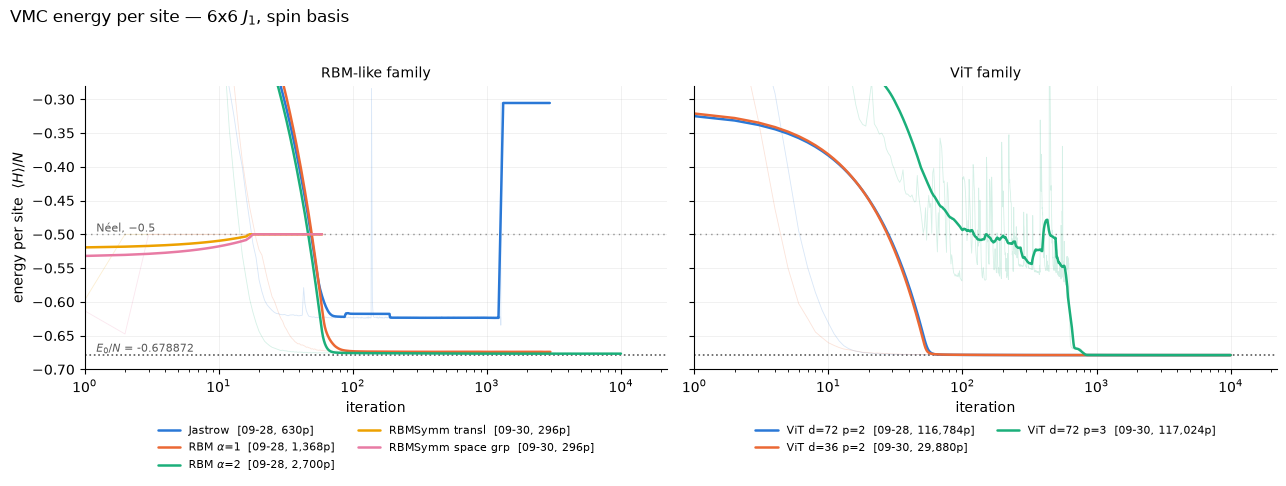

In [5]:
def smooth(y, w):
    w = min(w, max(1, len(y) // 4) * 2 + 1)
    if w < 3:
        return y
    k = np.ones(w) / w
    pad = w // 2
    return np.convolve(np.pad(y, pad, mode="edge"), k, mode="valid")


YLIM = (-0.70, -0.28)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.0), sharey=True)
for ax, panel in zip(axes, PANELS):
    members = [r for r in runs if r["panel"] == panel]
    for r in members:
        y = r["E"] / r["n_sites"]
        ax.plot(r["iters"], y, color=r["color"], lw=0.6, alpha=0.18)
        # No endpoint values here: at this scale every ViT reads -0.6789 and
        # both RBMSymm runs read -0.5000. The legend identifies the curves; the
        # numbers live in the table and the zoom below.
        ax.plot(r["iters"], smooth(y, SMOOTH), color=r["color"], lw=1.8,
                label=label(r), solid_capstyle="round")
    ax.axhline(E0_PER_SITE, color="0.35", ls=":", lw=1.2, zorder=0)
    ax.axhline(-0.5, color="0.55", ls=(0, (1, 3)), lw=1.0, zorder=0)
    ax.set_xscale("log")
    ax.set_xlim(1, 2.2e4)
    ax.set_ylim(*YLIM)
    ax.set_xlabel("iteration")
    ax.set_title(f"{panel} family", fontsize=10)
    ax.grid(alpha=0.2, lw=0.6)
    ax.set_axisbelow(True)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    # below the axes: with five entries, every in-axes corner of the left panel
    # collides with either a curve or a reference-line label
    ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.16),
              ncol=2, frameon=False)

axes[0].set_ylabel(r"energy per site  $\langle H\rangle / N$")
for txt, yv in ((f"$E_0/N$ = {E0_PER_SITE:.6f}", E0_PER_SITE),
                ("Néel, $-0.5$", -0.5)):
    axes[0].annotate(txt, xy=(0.02, yv), xycoords=("axes fraction", "data"),
                     ha="left", va="bottom", fontsize=8, color="0.35")
fig.suptitle("VMC energy per site — 6x6 $J_1$, spin basis", x=0.01, ha="left",
             fontsize=12, y=1.02)
fig.tight_layout()
fig.subplots_adjust(bottom=0.30)
plt.show()

## Zoom: the runs that actually converged

Linear iteration axis, restricted to the window around the reference, so only
the runs that got there appear. All three ViTs land within a line width of each
other — the relative-error figure below is what separates them.

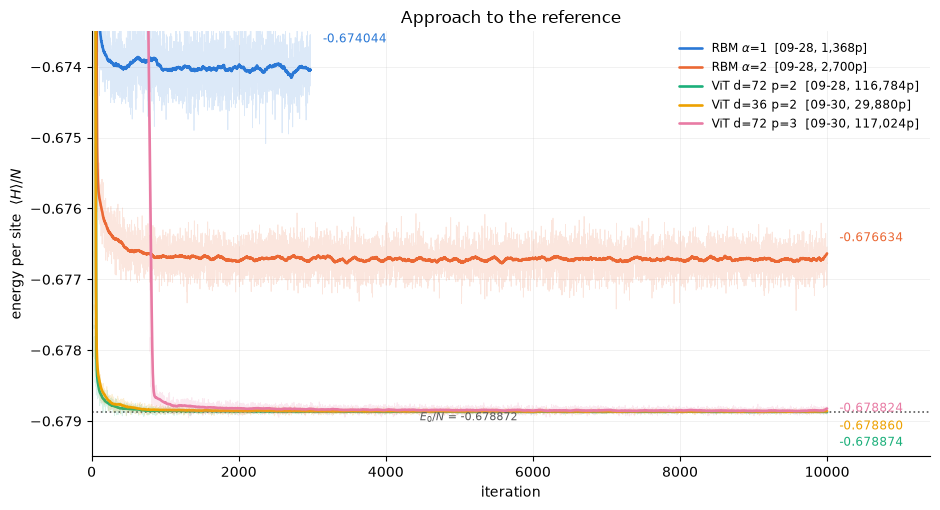

In [6]:
WIN = (-0.6795, -0.6735)
near = [r for r in runs if r["e_final"] < WIN[1]]

fig, ax = plt.subplots(figsize=(9.5, 5.2))
ends = []
for slot, r in enumerate(near):
    c = PALETTE[slot % len(PALETTE)]
    y = r["E"] / r["n_sites"]
    ax.plot(r["iters"], y, color=c, lw=0.6, alpha=0.16)
    ys = smooth(y, SMOOTH)
    ax.plot(r["iters"], ys, color=c, lw=1.9, label=label(r), solid_capstyle="round")
    ends.append((r["iters"][-1], ys[-1], c))

# The three ViTs land within a line width of each other, so spread their labels
# vertically by rank rather than letting them overprint.
ends.sort(key=lambda t: t[1])
for rank, (x, y, c) in enumerate(ends):
    dy = (rank - (len(ends) - 1) / 2) * 11
    ax.annotate(f" {y:.6f}", xy=(x, y), xytext=(6, dy),
                textcoords="offset points", ha="left", va="center",
                fontsize=8.5, color=c)
ax.axhline(E0_PER_SITE, color="0.35", ls=":", lw=1.2, zorder=0)
# below the line, mid-plot: nothing goes under the reference, and the right
# edge is taken by the staggered endpoint labels
ax.annotate(f"$E_0/N$ = {E0_PER_SITE:.6f}", xy=(0.45, E0_PER_SITE),
            xycoords=("axes fraction", "data"), ha="center", va="top",
            fontsize=8, color="0.35")
ax.set(xlabel="iteration", ylabel=r"energy per site  $\langle H\rangle / N$",
       title="Approach to the reference")
ax.set_xlim(0, max(r["iters"][-1] for r in near) * 1.14)
ax.set_ylim(*WIN)
ax.grid(alpha=0.2, lw=0.6)
ax.set_axisbelow(True)
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
ax.legend(fontsize=8.5, loc="upper right", frameon=False)
fig.tight_layout()
plt.show()

## Relative error vs. iteration

$|E - E_0| / |E_0|$ against the per-site reference — scale-invariant, so
total-vs-per-site is irrelevant. Smoothed only: the raw quantity spikes on a log
axis wherever the trace crosses the reference.

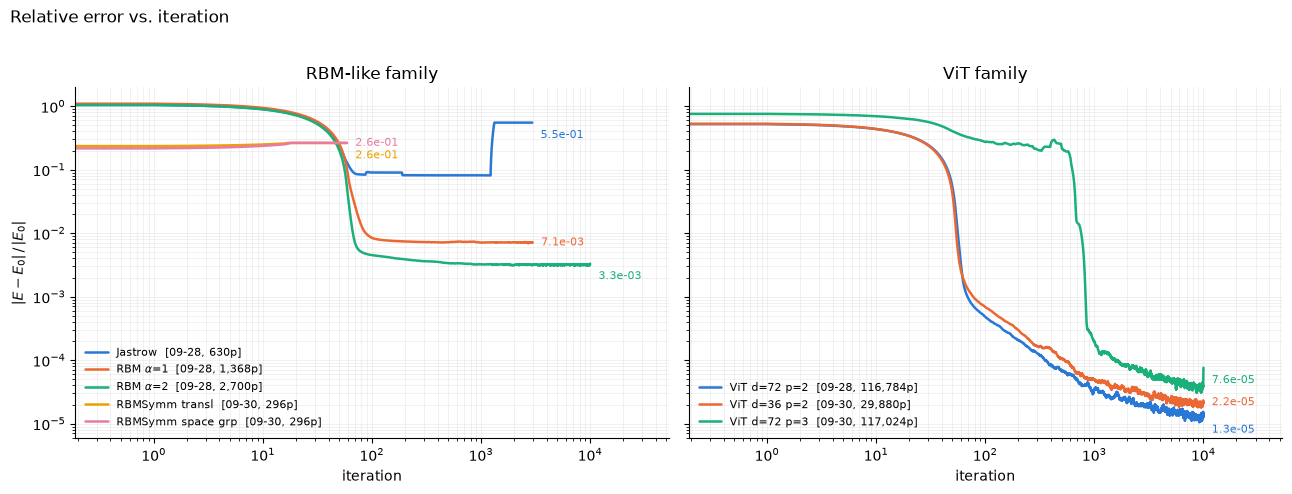

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, panel in zip(axes, PANELS):
    members = [r for r in runs if r["panel"] == panel]
    ends = []
    for r in members:
        rel = smooth(np.abs(r["E"] / r["n_sites"] - E0_PER_SITE) / abs(E0_PER_SITE),
                     SMOOTH)
        ax.loglog(r["iters"], rel, color=r["color"], lw=1.8, label=label(r),
                  solid_capstyle="round")
        ends.append((r["iters"][-1], rel[-1], r["color"]))
    for rank, (x, y, c) in enumerate(sorted(ends, key=lambda t: t[1])):
        ax.annotate(f"{y:.1e}", xy=(x, y), xytext=(6, -9 + 9 * (rank % 2)),
                    textcoords="offset points", ha="left", va="center",
                    fontsize=8, color=c)
    ax.set(xlabel="iteration", title=f"{panel} family")
    ax.margins(x=0.18)
    ax.grid(alpha=0.2, lw=0.6, which="both")
    ax.set_axisbelow(True)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    ax.legend(fontsize=8, loc="lower left", frameon=False)
axes[0].set_ylabel(r"$|E - E_0| \,/\, |E_0|$")
fig.suptitle("Relative error vs. iteration", x=0.01, ha="left", fontsize=12, y=1.02)
fig.tight_layout()
plt.show()

## Accuracy vs. parameter count

The question the symmetric RBMs were meant to answer: does imposing the lattice
symmetry buy accuracy per parameter? Every point is direct-labelled, so colour
is decoration here rather than the only identity cue. Collapsed runs are drawn
as crosses at the energy they froze at — they are failures, not data points on
an accuracy/size trade-off curve.

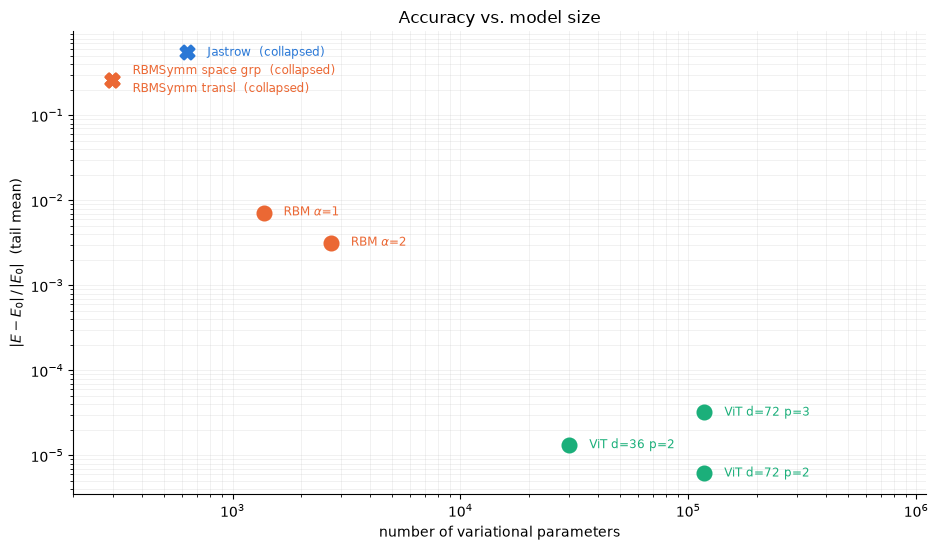

In [8]:
FAMILY_COLOR = {"jastrow": PALETTE[0], "rbm": PALETTE[1],
                "rbmsymm": PALETTE[1], "vit": PALETTE[2]}

fig, ax = plt.subplots(figsize=(9.5, 5.6))
for r in runs:
    dead = r["status"] == "frozen" or r["acc_final"] < 1e-3
    c = FAMILY_COLOR[r["family"]]
    ax.scatter(r["n_params"], r["rel_err"], s=95,
               marker="X" if dead else ("s" if r["family"] == "rbmsymm" else "o"),
               facecolor="none" if (r["family"] == "rbmsymm" and not dead) else c,
               edgecolor=c, linewidth=1.8, zorder=3)
    # the two RBMSymm runs sit on the same point (296p, same frozen energy),
    # so offset labels by rank within each coincident group
    group = [q for q in runs
             if abs(np.log10(q["n_params"] / r["n_params"])) < 0.02
             and abs(np.log10(q["rel_err"] / r["rel_err"])) < 0.02]
    dy = (group.index(r) - (len(group) - 1) / 2) * 13
    ax.annotate(f"  {r['name']}" + ("  (collapsed)" if dead else ""),
                xy=(r["n_params"], r["rel_err"]), xytext=(9, dy),
                textcoords="offset points", ha="left", va="center",
                fontsize=8.5, color=c)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set(xlabel="number of variational parameters",
       ylabel=r"$|E - E_0| \,/\, |E_0|$  (tail mean)",
       title="Accuracy vs. model size")
ax.set_xlim(2e2, 1.1e6)
ax.grid(alpha=0.2, lw=0.6, which="both")
ax.set_axisbelow(True)
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
fig.tight_layout()
plt.show()

## Sampling health

From `run.diag.jsonl`. `ESS_w` is omitted: `auto_alpha = false` everywhere here,
so the weights are all 1 and the panel is a flat line at 100%. The collapsed runs
appear as the short stubs on the left of the RBM-like column — acceptance
falling off a cliff between step 0 and step 20 is the whole story.

In [ ]:
DIAG_PANELS = [
    # Collapsed runs drive Var/site to ~1e-31 or exactly 0; clipping keeps the
    # band the healthy runs occupy readable.
    ("var_eloc_per_site",  r"Var$(E_{loc})/N$",  "log",  (1e-6, 3e0)),
    ("acceptance",         "acceptance",         None,   (0, 1.0)),
    ("rhat_logpsi",        r"$\hat{R}$  $\log|\psi|$",  None,  (0.99, 1.05)),
]
DIAG_SMOOTH = 9     # diag rows land every 20 steps -> ~180 steps

# Faceted by family like the figures above -- colour slots are assigned WITHIN
# a panel, so putting every run in one axes would make blue mean both Jastrow
# and ViT d=72 p=2.
fig, axes = plt.subplots(len(DIAG_PANELS), len(PANELS), figsize=(13, 8.0),
                         sharex=True, squeeze=False)
for row, (key, ylab, scale, ylim) in enumerate(DIAG_PANELS):
    for col, panel in enumerate(PANELS):
        ax = axes[row][col]
        for r in (x for x in runs if x["panel"] == panel):
            d = r["diag"]
            if not d:
                continue
            ax.plot(d["step"], d[key], color=r["color"], lw=0.7, alpha=0.18)
            ax.plot(d["step"], smooth(d[key], DIAG_SMOOTH), color=r["color"],
                    lw=1.5, label=label(r), solid_capstyle="round")
        if scale:
            ax.set_yscale(scale)
        if ylim:
            ax.set_ylim(*ylim)
        ax.grid(alpha=0.2, lw=0.6)
        ax.set_axisbelow(True)
        for sp in ("top", "right"):
            ax.spines[sp].set_visible(False)
        if row == 0:
            ax.set_title(f"{panel} family", fontsize=10)
        if row == len(DIAG_PANELS) - 1:
            ax.set_xlabel("iteration")
        if row == 2:
            ax.axhline(1.0, color="0.35", ls=":", lw=1.2, zorder=0)
        if col == 0:
            ax.set_ylabel(ylab)
    # the acceptance row is the one with free space in both columns
    axes[1][col].legend(fontsize=7.5, loc="upper right", frameon=False)
for col in range(len(PANELS)):
    axes[1][col].legend(fontsize=7.5, loc="upper right", frameon=False)
fig.suptitle("Sampling diagnostics", x=0.01, ha="left", fontsize=12, y=0.995)
fig.tight_layout()
plt.show()